# Preprocessing

### Outline
- Case Folding (Uppercase to Lowercase)
- Removing Noise (URLs, HTML tags, special characters, numbers)
- Tokenization
- Stopword Removal (before & after comparison)
- Lemmatization (root words / kata dasar)

## 1. Import Libraries & Load Data

In [65]:
# Install required libraries (run once)
!pip install pandas nltk sastrawi matplotlib seaborn wordcloud symspellpy


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [66]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Indonesian stemmer (for Bahasa Indonesia articles if applicable)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

print('All libraries loaded successfully.')

All libraries loaded successfully.


[nltk_data] Downloading package punkt to /home/lenovo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/lenovo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/lenovo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/lenovo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/lenovo/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/lenovo/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [67]:
df = pd.read_csv('../dataset/dataset.csv')

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded: 1001 rows, 4 columns
Columns: ['url', 'judul', 'konten', 'manual sentiment']


,url,judul,konten,manual sentiment
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive


## 2. Initial Data Exploration

In [68]:
df.columns = df.columns.str.strip().str.lower()

print('Column names after standardization:', list(df.columns))
print()
print(df.info())

Column names after standardization: ['url', 'judul', 'konten', 'manual sentiment']

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   url               1001 non-null   str  
 1   judul             1001 non-null   str  
 2   konten            1001 non-null   str  
 3   manual sentiment  1001 non-null   str  
dtypes: str(4)
memory usage: 4.3 MB
None


In [69]:
# Basic statistics
print('=== Dataset Overview ===')
print(f'Total articles     : {len(df)}')
print(f'Duplicate rows     : {df.duplicated().sum()}')
print(f'Missing values per column:')
print(df.isnull().sum())
print()

# Content length distribution
df['konten_length'] = df['konten'].astype(str).apply(len)
df['konten_word_count'] = df['konten'].astype(str).apply(lambda x: len(x.split()))

print(f'Content length (characters) - min: {df["konten_length"].min()}, '
      f'max: {df["konten_length"].max()}, '
      f'mean: {df["konten_length"].mean():.0f}')
print(f'Content word count - min: {df["konten_word_count"].min()}, '
      f'max: {df["konten_word_count"].max()}, '
      f'mean: {df["konten_word_count"].mean():.0f}')

=== Dataset Overview ===
Total articles     : 1001
Duplicate rows     : 0
Missing values per column:
url                 0
judul               0
konten              0
manual sentiment    0
dtype: int64

Content length (characters) - min: 154, max: 26287, mean: 4307
Content word count - min: 20, max: 3601, mean: 581


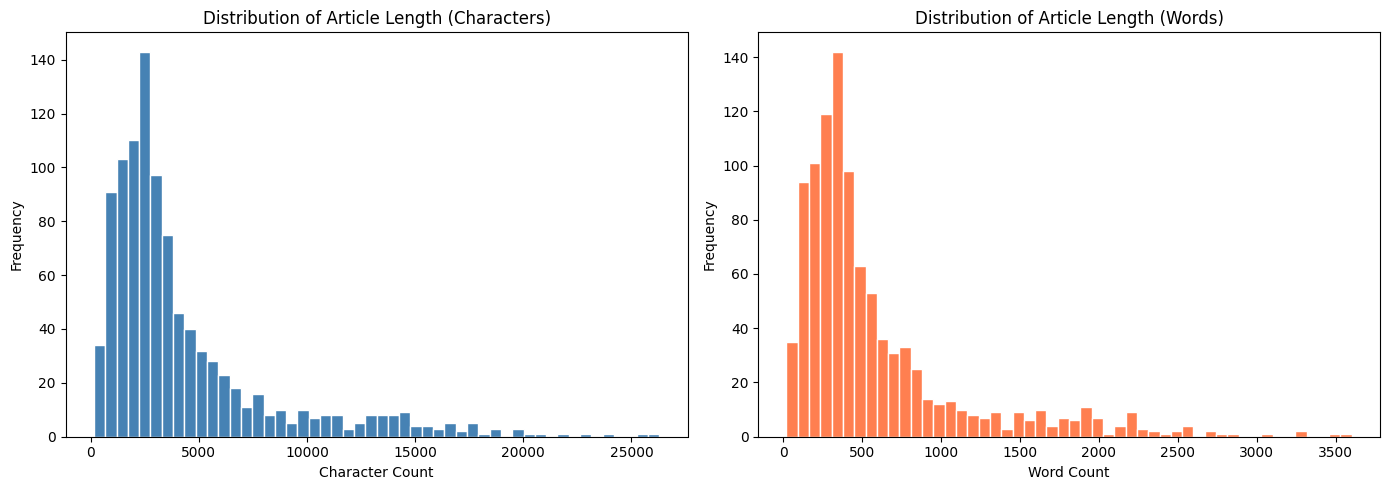

In [70]:
# Visualize content length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['konten_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Article Length (Characters)')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['konten_word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Article Length (Words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [71]:
# Remove duplicates
before_dedup = len(df)
df = df.drop_duplicates(subset=['konten'], keep='first').reset_index(drop=True)
after_dedup = len(df)
print(f'Removed {before_dedup - after_dedup} duplicate articles.')
print(f'Remaining articles: {after_dedup}')

Removed 2 duplicate articles.
Remaining articles: 999


In [72]:
# Remove rows with missing or empty content

before_clean = len(df)
df = df.dropna(subset=['konten']).reset_index(drop=True)
df = df[df['konten'].astype(str).str.strip() != ''].reset_index(drop=True)
after_clean = len(df)
print(f'Removed {before_clean - after_clean} rows with empty/missing content.')
print(f'Remaining articles: {after_clean}')

Removed 0 rows with empty/missing content.
Remaining articles: 999


## 4. Text Preprocessing Pipeline

The preprocessing pipeline includes:
1. Case folding (uppercase to lowercase)
2. Noise removal (URLs, HTML tags, special characters, extra whitespace)
3. Tokenization
4. Stopword removal
5. Lemmatization

### 4.1 Case Folding (Uppercase to Lowercase)

In [73]:
# Convert all text to lowercase
df['konten_clean'] = df['konten'].astype(str).str.lower()

print('Case folding completed.')
print('\nBefore (sample):')
print(df['konten'].iloc[0][:200])
print('\nAfter (sample):')
print(df['konten_clean'].iloc[0][:200])

Case folding completed.

Before (sample):
Jakarta, CNBC Indonesia -Amerika Serikat (AS) secara resmi memiliki Presiden baru yang disambut positif karena agenda pro-bisnis yang dibawanya.
Presiden Amerika Serikat (AS) Donald Trump resmi dilant

After (sample):
jakarta, cnbc indonesia -amerika serikat (as) secara resmi memiliki presiden baru yang disambut positif karena agenda pro-bisnis yang dibawanya.
presiden amerika serikat (as) donald trump resmi dilant


### 4.2 Noise Removal

In [ ]:
def remove_noise(text):
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove variations like [email protected], [EMAIL PROTECTED], etc.
    text = re.sub(r'\[\s*email\s+protected\s*\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'email protected', ' ', text)

    # Remove mentions
    text = re.sub(r'@\w+', ' ', text)

    # Remove hashtag symbol (keep the word)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove single characters (except 'a' and 'i' for English)
    text = re.sub(r'\b[b-hj-z]\b', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['konten_clean'] = df['konten_clean'].apply(remove_noise)

print('Noise removal completed.')
print('\nSample result:')
print(df['konten_clean'].iloc[0][:300])

Noise removal completed.

Sample result:
jakarta, cnbc indonesia -amerika serikat (as) secara resmi memiliki presiden baru yang disambut positif karena agenda pro-bisnis yang dibawanya. presiden amerika serikat (as) donald trump resmi dilantik pada senin waktu as ( / / ). secara umum, dalam pidatonya, trump mengungkapkan kebijakan perdagan


### 4.3 Tokenization

In [75]:
# Tokenize the cleaned text into individual words

df['tokens'] = df['konten_clean'].apply(word_tokenize)

print('Tokenization completed.')
print(f'\nSample tokens (first 20 tokens of first article):')
print(df['tokens'].iloc[0][:20])

Tokenization completed.

Sample tokens (first 20 tokens of first article):
['jakarta', ',', 'cnbc', 'indonesia', '-amerika', 'serikat', '(', 'as', ')', 'secara', 'resmi', 'memiliki', 'presiden', 'baru', 'yang', 'disambut', 'positif', 'karena', 'agenda', 'pro-bisnis']


In [76]:
df['konten_preprocessed'] = df['tokens'].apply(lambda x: ' '.join(x))

print('Final preprocessed text created.')
print('\nSample:')
print(df['konten_preprocessed'].iloc[0][:300])

Final preprocessed text created.

Sample:
jakarta , cnbc indonesia -amerika serikat ( as ) secara resmi memiliki presiden baru yang disambut positif karena agenda pro-bisnis yang dibawanya . presiden amerika serikat ( as ) donald trump resmi dilantik pada senin waktu as ( / / ) . secara umum , dalam pidatonya , trump mengungkapkan kebijakan


## 7. Export Preprocessed Dataset

In [77]:
df

,url,judul,konten,manual sentiment,konten_length,konten_word_count,konten_clean,tokens,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,1110,"jakarta, cnbc indonesia -amerika serikat (as) ...","[jakarta, ,, cnbc, indonesia, -amerika, serika...","jakarta , cnbc indonesia -amerika serikat ( as..."
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,399,"jakarta, cnbc indonesia -nilai tukar rupiah te...","[jakarta, ,, cnbc, indonesia, -nilai, tukar, r...","jakarta , cnbc indonesia -nilai tukar rupiah t..."
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,1747,"jakarta, cnbc indonesia-pasar keuangan indones...","[jakarta, ,, cnbc, indonesia-pasar, keuangan, ...","jakarta , cnbc indonesia-pasar keuangan indone..."
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,722,"jakarta, cnbc indonesia -indeks harga saham ga...","[jakarta, ,, cnbc, indonesia, -indeks, harga, ...","jakarta , cnbc indonesia -indeks harga saham g..."
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,616,hargabitcoin(btc)pernah melewati angka terting...,"[hargabitcoin, (, btc, ), pernah, melewati, an...",hargabitcoin ( btc ) pernah melewati angka ter...
...,...,...,...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,3756,506,jakarta - tiga produsen mesin penambang bitcoi...,"[jakarta, -, tiga, produsen, mesin, penambang,...",jakarta - tiga produsen mesin penambang bitcoi...
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Neutral,3322,447,presiden amerika serikat (as) donald trump men...,"[presiden, amerika, serikat, (, as, ), donald,...",presiden amerika serikat ( as ) donald trump m...
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,4713,627,"bisnis.com,jakarta — serangan amerika serikat ...","[bisnis.com, ,, jakarta, —, serangan, amerika,...","bisnis.com , jakarta — serangan amerika serika..."
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,2830,387,"jakarta, cnbc indonesia -perusahaan semikonduk...","[jakarta, ,, cnbc, indonesia, -perusahaan, sem...","jakarta , cnbc indonesia -perusahaan semikondu..."


In [78]:
df_export = df.copy()
df_export.drop(columns=['konten_word_count', 'konten_clean', 'tokens'], inplace=True)

df_export.head()

,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,"jakarta , cnbc indonesia -amerika serikat ( as..."
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,"jakarta , cnbc indonesia -nilai tukar rupiah t..."
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,"jakarta , cnbc indonesia-pasar keuangan indone..."
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,"jakarta , cnbc indonesia -indeks harga saham g..."
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin ( btc ) pernah melewati angka ter...


In [79]:
df_export.to_csv('../preprocessed/dataset_preprocessed_bert.csv', index=False, encoding='utf-8')
print(f'Export dataset shape: {df_export.shape}')
print(f'Columns: {list(df_export.columns)}')

Export dataset shape: (999, 6)
Columns: ['url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']


In [80]:
df_export

,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,"jakarta , cnbc indonesia -amerika serikat ( as..."
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,"jakarta , cnbc indonesia -nilai tukar rupiah t..."
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,"jakarta , cnbc indonesia-pasar keuangan indone..."
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,"jakarta , cnbc indonesia -indeks harga saham g..."
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin ( btc ) pernah melewati angka ter...
...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,3756,jakarta - tiga produsen mesin penambang bitcoi...
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Neutral,3322,presiden amerika serikat ( as ) donald trump m...
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,4713,"bisnis.com , jakarta — serangan amerika serika..."
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,2830,"jakarta , cnbc indonesia -perusahaan semikondu..."


In [ ]:
# Select columns to export
export_cols = [
    'url',                         # Original URL
    'judul',                       # Original title
    'konten',                      # Original content (raw)
    # 'konten_clean',                # After case folding + noise removal
    # 'text_before_stopwords',       # Tokenized text before stopwords
    # 'n_tokens_before_stopwords',   # Token count before stopwords
    # 'text_after_stopwords',        # Text after stopword removal
    # 'n_tokens_after_stopwords',    # Token count after stopwords
    'konten_clean',         # Final preprocessed text (lemmatized)
    # 'tokens_lemmatized',           # Lemmatized token list
]

export_cols = [col for col in export_cols if col in df.columns]

df_export = df[export_cols].copy()

if 'tokens_lemmatized' in df_export.columns:
    df_export['tokens_lemmatized'] = df_export['tokens_lemmatized'].apply(
        lambda x: '|'.join(x) if isinstance(x, list) else x
    )

print(f'Export dataset shape: {df_export.shape}')
print(f'Columns: {list(df_export.columns)}')
df_export.head()

Export dataset shape: (999, 4)
Columns: ['url', 'judul', 'konten', 'konten_clean']


,url,judul,konten,konten_clean
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...","jakarta, cnbc indonesia -amerika serikat (as) ..."
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...","jakarta, cnbc indonesia -nilai tukar rupiah te..."
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...","jakarta, cnbc indonesia-pasar keuangan indones..."
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...","jakarta, cnbc indonesia -indeks harga saham ga..."
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,hargabitcoin(btc)pernah melewati angka terting...
